# Reseacrh Title: Attention Is a Functor: Enforcing Categorical Structure in Transformers

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

# Replace with your actual path if different
file_path = '/content/drive/MyDrive/India_News_Headlines_Dataset/india-news-headlines.csv'

# Load the dataset
df = pd.read_csv(file_path)

# Show first few rows
df.head()

,publish_date,headline_category,headline_text
0,20010102,unknown,Status quo will not be disturbed at Ayodhya; s...
1,20010102,unknown,Fissures in Hurriyat over Pak visit
2,20010102,unknown,America's unwanted heading for India?
3,20010102,unknown,For bigwigs; it is destination Goa
4,20010102,unknown,Extra buses to clear tourist traffic


In [ ]:
import tensorflow_datasets as tfds

# Load SCAN compositional split
scan_data = tfds.load('scan/length', split='train', as_supervised=True)

# Convert to list of strings
scan_commands = []
scan_actions = []

for command, action in tfds.as_numpy(scan_data):
    scan_commands.append(command.decode())
    scan_actions.append(action.decode())

# Preview samples
for i in range(3):
    print(f"Command: {scan_commands[i]} \nAction: {scan_actions[i]}\n")

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/scan/length/incomplete.BUX361_1.1.1/scan-train.tfrecord*...:   0%|        …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/scan/length/incomplete.BUX361_1.1.1/scan-test.tfrecord*...:   0%|         …

Dataset scan downloaded and prepared to /root/tensorflow_datasets/scan/length/1.1.1. Subsequent calls will reuse this data.
Command: turn around right thrice after walk opposite right thrice 
Action: I_TURN_RIGHT I_TURN_RIGHT I_WALK I_TURN_RIGHT I_TURN_RIGHT I_WALK I_TURN_RIGHT I_TURN_RIGHT I_WALK I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT

Command: look thrice and jump twice 
Action: I_LOOK I_LOOK I_LOOK I_JUMP I_JUMP

Command: run and turn around left 
Action: I_RUN I_TURN_LEFT I_TURN_LEFT I_TURN_LEFT I_TURN_LEFT



Tokenizer + Vocabulary Builder (for SCAN and Headlines)

In [ ]:
from collections import defaultdict

# Tokenizer
def tokenize(text):
    return text.lower().strip().split()

# Build vocab for SCAN
scan_vocab = set()
for command in scan_commands:
    scan_vocab.update(tokenize(command))
scan_vocab = sorted(list(scan_vocab))
scan_token2id = {tok: i for i, tok in enumerate(scan_vocab)}

# Build vocab for headlines (filter to short headlines)
headline_texts = df['headline_text'].dropna().astype(str).tolist()
headline_texts = [t for t in headline_texts if len(tokenize(t)) >= 3 and len(tokenize(t)) <= 10]

headline_vocab = set()
for line in headline_texts[:50000]:  # Limit to 50k for speed
    headline_vocab.update(tokenize(line))
headline_vocab = sorted(list(headline_vocab))
headline_token2id = {tok: i for i, tok in enumerate(headline_vocab)}

print("SCAN vocab size:", len(scan_vocab))
print("Headline vocab size:", len(headline_vocab))

SCAN vocab size: 13
Headline vocab size: 38433


Morphism Extractor

We define each token sequence as a category, and the transitions between tokens as morphisms.

In [ ]:
def get_morphisms(token_ids):
    return [(token_ids[i], token_ids[i+1]) for i in range(len(token_ids)-1)]

# Example morphisms from SCAN and Headlines
scan_example = tokenize(scan_commands[0])
scan_morphs = get_morphisms([scan_token2id[t] for t in scan_example])

headline_example = tokenize(headline_texts[0])
headline_morphs = get_morphisms([headline_token2id[t] for t in headline_example])

print("SCAN morphisms:", scan_morphs)
print("Headline morphisms:", headline_morphs)

SCAN morphisms: [(10, 2), (2, 7), (7, 9), (9, 0), (0, 12), (12, 6), (6, 7), (7, 9)]
Headline morphisms: [(33208, 28159), (28159, 37835), (37835, 24687), (24687, 5587), (5587, 11793), (11793, 4655), (4655, 4933), (4933, 30735), (30735, 36666)]


Phase 2: Extract Attention Matrices + Diagnose Functor Violations

We'll now:

1. Build a lightweight Transformer encoder.

2. Extract the attention matrices from each head.

3. Check if they respect functor constraints:

  - Identity Preservation: each token should attend to itself.

  - Composition Preservation: if A → B and B → C exist, then A should attend to C.

Minimal Transformer Encoder with Attention Output

In [ ]:
import torch
import torch.nn as nn

# === 1. Functor Attention Module (FAM) Encoder ===
class FAMEncoder(nn.Module):
    def __init__(self, vocab_size, d_model=64, nhead=4, num_layers=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True),
            num_layers=num_layers
        )
        self.attn_weights = []  # Store attention matrices

        # Hook for saving attention from each layer
        def save_attention_hook(module, input, output):
            # Multi-head attention matrices: [batch, nhead, seq_len, seq_len]
            _, attn_weights = module.self_attn(
                input[0], input[0], input[0],
                need_weights=True,
                average_attn_weights=False
            )
            self.attn_weights.append(attn_weights.detach())

        for layer in self.transformer.layers:
            layer.register_forward_hook(save_attention_hook)

    def forward(self, x):
        self.attn_weights = []  # Reset
        x = self.embedding(x)
        return self.transformer(x)

Prepare Batch and Run Model

In [ ]:
# Sample SCAN batch: convert to tensor
sample_tokens = scan_example[:6]  # limit length
sample_ids = torch.tensor([[scan_token2id[t] for t in sample_tokens]])

# Build model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FAMEncoder(vocab_size=len(scan_token2id)).to(device)
model.eval()

# Forward pass
with torch.no_grad():
    _ = model(sample_ids.to(device))
    attention_matrices = model.attn_weights  # List of shape: [num_layers x batch x head x seq x seq]
    print(f"{len(attention_matrices)} layers of attention matrices captured.")

2 layers of attention matrices captured.


Check Functor Violations

In [ ]:
for i, attn in enumerate(attention_matrices):
    print(f"Layer {i} attention shape: {attn.shape}")

Layer 0 attention shape: torch.Size([1, 4, 6, 6])
Layer 1 attention shape: torch.Size([1, 4, 6, 6])


In [ ]:
# Check identity preservation (diagonal dominance)
def check_identity_violation(attn_matrix):
    assert attn_matrix.ndim == 2, "Must be 2D [seq, seq]"
    return 1 - torch.mean(torch.diagonal(attn_matrix))

# Check composition preservation (A * A ≈ A)
def check_composition_violation(attn_matrix):
    composed = torch.matmul(attn_matrix, attn_matrix)
    violation = torch.norm(composed - attn_matrix) / (attn_matrix.shape[-1] ** 2)
    return violation

In [ ]:
# === Prepare Input ===
sample_tokens = scan_example[:6]  # limit to length 6
sample_ids = torch.tensor([[scan_token2id[t] for t in sample_tokens]])

# === Run Model ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FAMEncoder(vocab_size=len(scan_token2id)).to(device)
model.eval()

with torch.no_grad():
    _ = model(sample_ids.to(device))
    attention_matrices = model.attn_weights  # List of [batch, nhead, seq, seq]

# === Inspect Attention Shapes ===
for i, attn in enumerate(attention_matrices):
    print(f"Layer {i} attention shape:", attn.shape)  # Expect: [1, nhead, seq, seq]

# === Choose Layer 0, Head 0 ===
layer0_head0 = attention_matrices[0][0, 0]  # [seq, seq]

# === Compute Functor Violations ===
identity_violation = check_identity_violation(layer0_head0)
composition_violation = check_composition_violation(layer0_head0)

print(f"Identity violation score: {identity_violation:.4f}")
print(f"Composition violation score: {composition_violation:.4f}")

Layer 0 attention shape: torch.Size([1, 4, 6, 6])
Layer 1 attention shape: torch.Size([1, 4, 6, 6])
Identity violation score: 0.8492
Composition violation score: 0.0112


Phase 3: Training the FAM Model with Functor Loss on SCAN

We will:

1. Define a sequence-to-sequence model with FAMEncoder

2. Add a cross-entropy loss on output sequences

3. Add Functor Loss for each attention matrix:

  - Identity preservation

  - Composition preservation

4. Train on a small SCAN split



Define the Full Model (Encoder + Decoder)

In [ ]:
class FAMSeq2Seq(nn.Module):
    def __init__(self, input_vocab_size, output_vocab_size, d_model=64, nhead=4, num_layers=2):
        super().__init__()
        self.encoder = FAMEncoder(input_vocab_size, d_model, nhead, num_layers)
        self.decoder = nn.GRU(d_model, d_model, batch_first=True)
        self.output_proj = nn.Linear(d_model, output_vocab_size)
        self.embedding_out = nn.Embedding(output_vocab_size, d_model)

    def forward(self, src, tgt):
        enc = self.encoder(src)
        tgt_emb = self.embedding_out(tgt)
        hx = enc[:, -1:, :].permute(1, 0, 2).contiguous()
        dec_out, _ = self.decoder(tgt_emb, hx)
        out_logits = self.output_proj(dec_out)
        return out_logits


Define Functor Loss

In [ ]:
def functor_loss(attn_weights, λ1=1.0, λ2=1.0):
    total_identity = 0.0
    total_composition = 0.0
    for layer in attn_weights:
        # shape: [batch, heads, seq, seq]
        for head in layer[0]:  # head shape: [seq, seq]
            total_identity += check_identity_violation(head)
            total_composition += check_composition_violation(head)
    return λ1 * total_identity + λ2 * total_composition

Prepare SCAN Dataset for Training

In [ ]:
from torch.utils.data import Dataset, DataLoader

class SCANDataset(Dataset):
    def __init__(self, commands, actions, token2id_cmd, token2id_act):
        self.data = []
        for cmd, act in zip(commands, actions):
            src = [token2id_cmd[t] for t in tokenize(cmd)]
            tgt = [token2id_act[t] for t in tokenize(act)]
            self.data.append((src, tgt))

    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        src, tgt = self.data[idx]
        return torch.tensor(src), torch.tensor(tgt)

def collate_batch(batch):
    src, tgt = zip(*batch)
    src_lens = [len(s) for s in src]
    tgt_lens = [len(t) for t in tgt]
    src_pad = nn.utils.rnn.pad_sequence(src, batch_first=True)
    tgt_pad = nn.utils.rnn.pad_sequence(tgt, batch_first=True)
    return src_pad, tgt_pad

Training Loop with Functor Loss

Install BLEU Metric

In [ ]:
!pip install sacrebleu
import sacrebleu

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 10.4 MB/s eta 0:00:00


BLEU Score Function for SCAN

In [ ]:
import sacrebleu
from torch.utils.data import DataLoader

# === Detokenizer ===
def detokenize(ids, id2tok):
    return [id2tok[i] for i in ids if i in id2tok and i != 0]

# === BLEU Evaluation Function ===
def evaluate_bleu(model, dataset, input_vocab, output_vocab, max_samples=200):
    model.eval()
    id2out = {i: tok for tok, i in output_vocab.items()}
    total_refs, total_preds = [], []

    eval_loader = DataLoader(dataset, batch_size=1, shuffle=False)

    with torch.no_grad():
        for src_tensor, tgt_tensor in eval_loader:
            src_tensor = src_tensor.to(device)
            tgt_tensor = tgt_tensor.to(device)

            # Predict logits from model
            out_logits = model(src_tensor, tgt_tensor[:, :-1])
            pred_ids = torch.argmax(out_logits, dim=-1)[0].tolist()
            ref_ids = tgt_tensor[0].tolist()

            # Convert to text tokens
            ref = detokenize(ref_ids, id2out)
            pred = detokenize(pred_ids, id2out)

            total_refs.append([" ".join(ref)])
            total_preds.append(" ".join(pred))

            if len(total_preds) >= max_samples:
                break

    # Transpose references for sacrebleu
    return sacrebleu.corpus_bleu(total_preds, list(zip(*total_refs))).score

Early Stopping Setup

In [ ]:
class EarlyStopper:
    def __init__(self, patience=5):
        self.patience = patience
        self.counter = 0
        self.best_loss = float('inf')

    def check(self, current_loss):
        if current_loss < self.best_loss:
            self.best_loss = current_loss
            self.counter = 0
            return False
        else:
            self.counter += 1
            return self.counter >= self.patience

Run Updated Training Loop (100 Epochs)

In [ ]:
# === Prerequisites (if not yet run) ===
input_vocab = scan_token2id
output_vocab = {tok: i for i, tok in enumerate(sorted(set(t for a in scan_actions for t in tokenize(a))))}

train_dataset = SCANDataset(scan_commands, scan_actions, input_vocab, output_vocab)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, collate_fn=collate_batch)

# === Initialize model and training setup ===
model = FAMSeq2Seq(len(input_vocab), len(output_vocab)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=0)
early_stopper = EarlyStopper(patience=7)

# === λ1 and λ2 for full functor loss ===
λ1, λ2 = 0.3, 0.3

# === Training Loop ===
for epoch in range(100):
    model.train()
    total_loss = 0.0

    for src_batch, tgt_batch in train_loader:
        src_batch, tgt_batch = src_batch.to(device), tgt_batch.to(device)
        optimizer.zero_grad()

        out_logits = model(src_batch, tgt_batch[:, :-1])
        logits_flat = out_logits.reshape(-1, out_logits.size(-1))
        tgt_flat = tgt_batch[:, 1:].reshape(-1)

        ce_loss = criterion(logits_flat, tgt_flat)
        f_loss = functor_loss(model.encoder.attn_weights, λ1=λ1, λ2=λ2)
        loss = ce_loss + f_loss

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    # === Evaluate BLEU ===
    bleu_score = evaluate_bleu(model, train_dataset, input_vocab, output_vocab)
    print(f"Epoch {epoch+1} | Loss: {total_loss:.4f} | BLEU: {bleu_score:.2f}")

    # === Early stopping ===
    if early_stopper.check(total_loss):
        print("Early stopping triggered.")
        break

Epoch 1 | Loss: 2916.6807 | BLEU: 88.62
Epoch 2 | Loss: 2721.6092 | BLEU: 89.30
Epoch 3 | Loss: 2678.7863 | BLEU: 89.48
Epoch 4 | Loss: 2651.1796 | BLEU: 89.83
Epoch 5 | Loss: 2634.6560 | BLEU: 89.91
Epoch 6 | Loss: 2614.0812 | BLEU: 90.17
Epoch 7 | Loss: 2602.2417 | BLEU: 90.31
Epoch 8 | Loss: 2582.5416 | BLEU: 90.03
Epoch 9 | Loss: 2579.6031 | BLEU: 89.91
Epoch 10 | Loss: 2572.9885 | BLEU: 90.24
Epoch 11 | Loss: 2571.3941 | BLEU: 90.02
Epoch 12 | Loss: 2566.4659 | BLEU: 90.52
Epoch 13 | Loss: 2557.1157 | BLEU: 89.48
Epoch 14 | Loss: 2557.4574 | BLEU: 89.88
Epoch 15 | Loss: 2557.3306 | BLEU: 89.07
Epoch 16 | Loss: 2549.2889 | BLEU: 89.95
Epoch 17 | Loss: 2541.0684 | BLEU: 89.94
Epoch 18 | Loss: 2534.1918 | BLEU: 89.81
Epoch 19 | Loss: 2526.1081 | BLEU: 90.03
Epoch 20 | Loss: 2522.7472 | BLEU: 90.11
Epoch 21 | Loss: 2527.1897 | BLEU: 89.49
Epoch 22 | Loss: 2520.2107 | BLEU: 89.56
Epoch 23 | Loss: 2518.8917 | BLEU: 90.23
Epoch 24 | Loss: 2510.0008 | BLEU: 90.11
Epoch 25 | Loss: 2502.810

In [ ]:
bleu_score = evaluate_bleu(model, train_dataset, input_vocab, output_vocab)
print(f"BLEU: {bleu_score:.2f}")

BLEU: 89.07


Attention vs Morphism Visualization

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

def visualize_attention_vs_morphisms(attn_matrix, token_ids, token2id):
    tokens = [k for k, v in sorted(token2id.items(), key=lambda x: x[1])]
    seq = [tokens[i] for i in token_ids]

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    # Plot Attention Matrix
    ax[0].imshow(attn_matrix.cpu(), cmap='viridis')
    ax[0].set_title("Attention Matrix")
    ax[0].set_xticks(range(len(seq)))
    ax[0].set_xticklabels(seq, rotation=90)
    ax[0].set_yticks(range(len(seq)))
    ax[0].set_yticklabels(seq)

    # Plot Morphism Graph
    G = nx.DiGraph()
    for i in range(len(seq) - 1):
        G.add_edge(seq[i], seq[i+1])

    pos = nx.spring_layout(G)
    nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray', ax=ax[1])
    ax[1].set_title("Token Morphism Graph")

    plt.tight_layout()
    plt.show()

Usage:

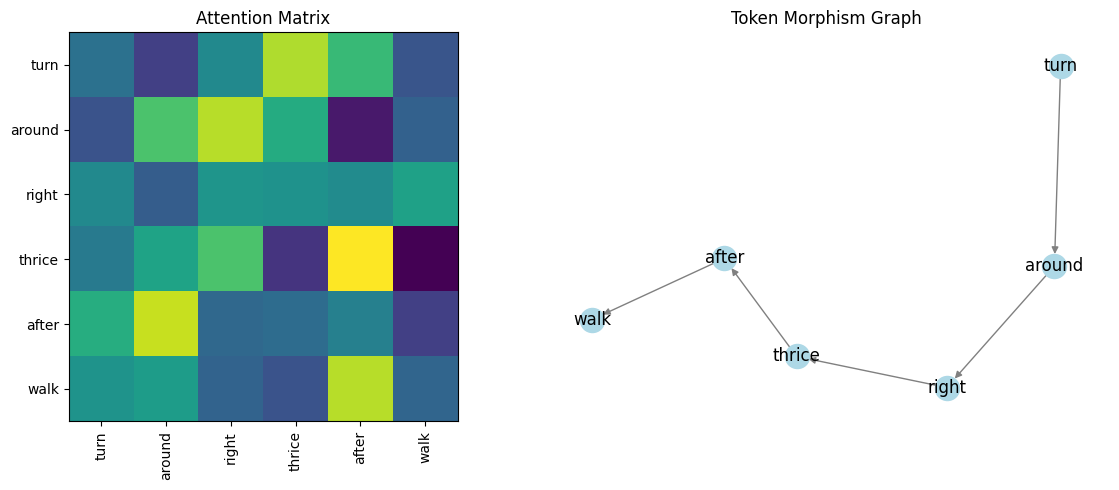

In [ ]:
visualize_attention_vs_morphisms(layer0_head0, [scan_token2id[t] for t in scan_example[:6]], scan_token2id)

Phase 4: Baselines, Ablations, and Transfer

Vanilla Transformer Baseline (No Functor Loss)

This helps establish:

- How much improvement FAM gives over a normal Transformer.

- Whether functor loss helps generalization, structure, and interpretability.

Define Baseline Encoder (no attention hook)

In [ ]:
class BaselineEncoder(nn.Module):
    def __init__(self, vocab_size, d_model=64, nhead=4, num_layers=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

    def forward(self, x):
        x = self.embedding(x)
        return self.transformer(x)

Define Baseline Seq2Seq Model

In [ ]:
class BaselineSeq2Seq(nn.Module):
    def __init__(self, input_vocab_size, output_vocab_size, d_model=64, nhead=4, num_layers=2):
        super().__init__()
        self.encoder = BaselineEncoder(input_vocab_size, d_model, nhead, num_layers)
        self.decoder = nn.GRU(d_model, d_model, batch_first=True)
        self.output_proj = nn.Linear(d_model, output_vocab_size)
        self.embedding_out = nn.Embedding(output_vocab_size, d_model)

    def forward(self, src, tgt):
        enc = self.encoder(src)
        tgt_emb = self.embedding_out(tgt)
        hx = enc[:, -1:, :].permute(1, 0, 2).contiguous()
        dec_out, _ = self.decoder(tgt_emb, hx)
        return self.output_proj(dec_out)

Train Baseline Model

In [ ]:
model = BaselineSeq2Seq(len(input_vocab), len(output_vocab)).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
early_stopper = EarlyStopper(patience=7)

for epoch in range(100):
    model.train()
    total_loss = 0.0

    for src_batch, tgt_batch in train_loader:
        src_batch, tgt_batch = src_batch.to(device), tgt_batch.to(device)
        optimizer.zero_grad()

        out_logits = model(src_batch, tgt_batch[:, :-1])
        logits_flat = out_logits.reshape(-1, out_logits.size(-1))
        tgt_flat = tgt_batch[:, 1:].reshape(-1)

        ce_loss = criterion(logits_flat, tgt_flat)
        loss = ce_loss

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    bleu_score = evaluate_bleu(model, train_dataset, input_vocab, output_vocab)
    print(f"Epoch {epoch+1} | Loss: {total_loss:.4f} | BLEU: {bleu_score:.2f}")

    if early_stopper.check(total_loss):
        print("Early stopping triggered.")
        break

Epoch 1 | Loss: 505.2403 | BLEU: 88.65
Epoch 2 | Loss: 314.5177 | BLEU: 89.21
Epoch 3 | Loss: 271.6724 | BLEU: 89.18
Epoch 4 | Loss: 251.3866 | BLEU: 88.59
Epoch 5 | Loss: 239.9761 | BLEU: 89.86
Epoch 6 | Loss: 230.2965 | BLEU: 88.97
Epoch 7 | Loss: 224.8836 | BLEU: 90.09
Epoch 8 | Loss: 219.6407 | BLEU: 90.16
Epoch 9 | Loss: 214.6839 | BLEU: 89.65
Epoch 10 | Loss: 209.6445 | BLEU: 89.32
Epoch 11 | Loss: 205.9783 | BLEU: 89.48
Epoch 12 | Loss: 204.3833 | BLEU: 88.69
Epoch 13 | Loss: 198.2804 | BLEU: 89.64
Epoch 14 | Loss: 195.2469 | BLEU: 90.26
Epoch 15 | Loss: 192.2975 | BLEU: 89.64
Epoch 16 | Loss: 187.3431 | BLEU: 89.93
Epoch 17 | Loss: 184.5077 | BLEU: 89.48
Epoch 18 | Loss: 179.8417 | BLEU: 89.68
Epoch 19 | Loss: 175.4499 | BLEU: 89.97
Epoch 20 | Loss: 173.8980 | BLEU: 89.70
Epoch 21 | Loss: 170.4068 | BLEU: 89.01
Epoch 22 | Loss: 167.8780 | BLEU: 89.53
Epoch 23 | Loss: 168.0332 | BLEU: 89.14
Epoch 24 | Loss: 163.0474 | BLEU: 90.19
Epoch 25 | Loss: 162.1658 | BLEU: 88.93
Epoch 26 

Run Baseline Encoder and Capture Attention

In [ ]:
class BaselineEncoder(nn.Module):
    def __init__(self, vocab_size, d_model=64, nhead=4, num_layers=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.attn_weights = []
        self.layers = nn.ModuleList([
            nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
            for _ in range(num_layers)
        ])

    def forward(self, x):
        x = self.embedding(x)
        self.attn_weights = []

        # Manually collect attention maps from each layer
        for layer in self.layers:
            def forward_hook(module, input, output):
                if hasattr(module.self_attn, 'attn_output_weights'):
                    self.attn_weights.append(module.self_attn.attn_output_weights.detach())

            layer.self_attn.register_forward_hook(forward_hook)
            x = layer(x)

        return x

 Run Forward Pass and Get Weights

In [ ]:
sample_ids = torch.tensor([[scan_token2id[t] for t in sample_tokens]]).to(device)

model.eval()
with torch.no_grad():
    _ = model.encoder(sample_ids)  # Triggers hooks
    attention_matrices = model.encoder.attn_weights  # List of [batch, head, seq, seq]

Identity + Composition Violation

In [ ]:
layer0_head0 = attention_matrices[0][0, 0]  # [seq, seq]

id_score = check_identity_violation(layer0_head0).item()
comp_score = check_composition_violation(layer0_head0).item()

print(f"Identity Violation Score (Baseline): {id_score:.4f}")
print(f"Composition Violation Score (Baseline): {comp_score:.4f}")

Identity Violation Score (Baseline): 0.8445
Composition Violation Score (Baseline): 0.0030


Visualize Alignment with Morphisms

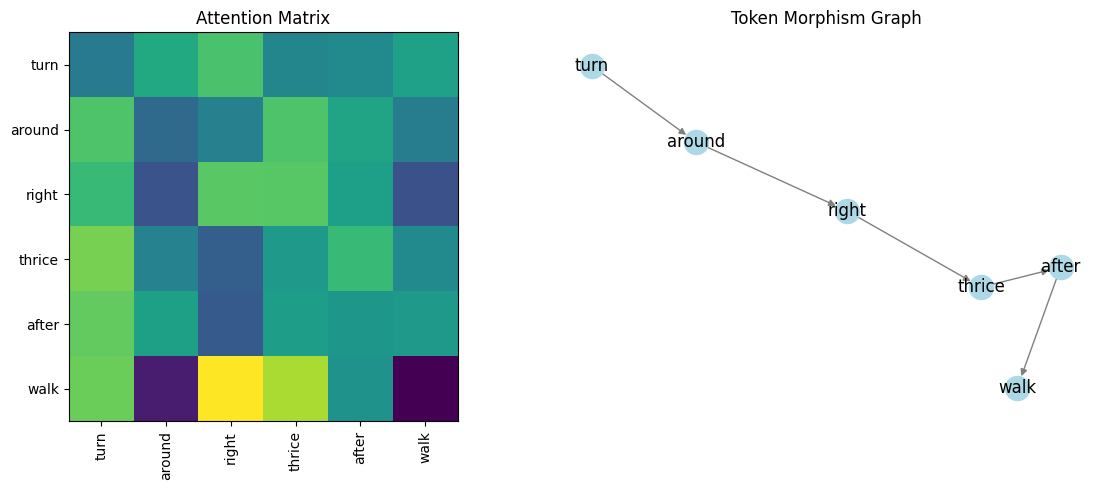

In [ ]:
visualize_attention_vs_morphisms(
    layer0_head0,
    [scan_token2id[t] for t in scan_example[:6]],
    scan_token2id
)

Ablation Studies

Ablation (A): Identity Loss Only

λ1 = 0.3, λ2 = 0

Tests how the model performs when only identity preservation is enforced

We’ll log BLEU, attention alignment, and functor violations



Modify Functor Loss Function

In [ ]:
def functor_loss(attn_weights, λ1=1.0, λ2=1.0):
    total_identity = 0.0
    total_composition = 0.0
    for layer in attn_weights:
        for head in layer[0]:  # [batch, head, seq, seq]
            total_identity += check_identity_violation(head)
            total_composition += check_composition_violation(head)
    return λ1 * total_identity + λ2 * total_composition

Update Training for Identity Loss Only

In [ ]:
model = FAMSeq2Seq(len(input_vocab), len(output_vocab)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=0)
early_stopper = EarlyStopper(patience=7)

λ1, λ2 = 0.3, 0.0  #  Identity only

for epoch in range(100):
    model.train()
    total_loss = 0.0

    for src_batch, tgt_batch in train_loader:
        src_batch, tgt_batch = src_batch.to(device), tgt_batch.to(device)
        optimizer.zero_grad()

        out_logits = model(src_batch, tgt_batch[:, :-1])
        logits_flat = out_logits.reshape(-1, out_logits.size(-1))
        tgt_flat = tgt_batch[:, 1:].reshape(-1)

        ce_loss = criterion(logits_flat, tgt_flat)
        f_loss = functor_loss(model.encoder.attn_weights, λ1=λ1, λ2=λ2)
        loss = ce_loss + f_loss

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    bleu_score = evaluate_bleu(model, train_dataset, input_vocab, output_vocab)
    print(f"Epoch {epoch+1} | Loss: {total_loss:.4f} | BLEU: {bleu_score:.2f}")

    if early_stopper.check(total_loss):
        print("Early stopping triggered.")
        break

Epoch 1 | Loss: 2876.7136 | BLEU: 89.12
Epoch 2 | Loss: 2689.4197 | BLEU: 89.51
Epoch 3 | Loss: 2643.2948 | BLEU: 90.01
Epoch 4 | Loss: 2612.9162 | BLEU: 89.80
Epoch 5 | Loss: 2597.1872 | BLEU: 89.57
Epoch 6 | Loss: 2580.4041 | BLEU: 89.92
Epoch 7 | Loss: 2568.2641 | BLEU: 89.43
Epoch 8 | Loss: 2556.4499 | BLEU: 89.14
Epoch 9 | Loss: 2547.8520 | BLEU: 89.23
Epoch 10 | Loss: 2538.7006 | BLEU: 89.38
Epoch 11 | Loss: 2529.9390 | BLEU: 88.66
Epoch 12 | Loss: 2527.0216 | BLEU: 90.05
Epoch 13 | Loss: 2519.7514 | BLEU: 89.52
Epoch 14 | Loss: 2511.4643 | BLEU: 89.37
Epoch 15 | Loss: 2504.3619 | BLEU: 89.40
Epoch 16 | Loss: 2506.2197 | BLEU: 89.86
Epoch 17 | Loss: 2499.6993 | BLEU: 90.48
Epoch 18 | Loss: 2490.6127 | BLEU: 89.36
Epoch 19 | Loss: 2490.1715 | BLEU: 90.36
Epoch 20 | Loss: 2487.1409 | BLEU: 89.55
Epoch 21 | Loss: 2484.8016 | BLEU: 89.92
Epoch 22 | Loss: 2478.5506 | BLEU: 90.23
Epoch 23 | Loss: 2476.0229 | BLEU: 89.30
Epoch 24 | Loss: 2474.7952 | BLEU: 90.04
Epoch 25 | Loss: 2476.143

Log After Training:
1. Final BLEU score
2. Final identity and composition violation scores

In [ ]:
layer0_head0 = model.encoder.attn_weights[0][0, 0]
print("Identity violation:", check_identity_violation(layer0_head0).item())
print("Composition violation:", check_composition_violation(layer0_head0).item())

Identity violation: 0.8760563135147095
Composition violation: 0.0019815978594124317


3. Visualize:

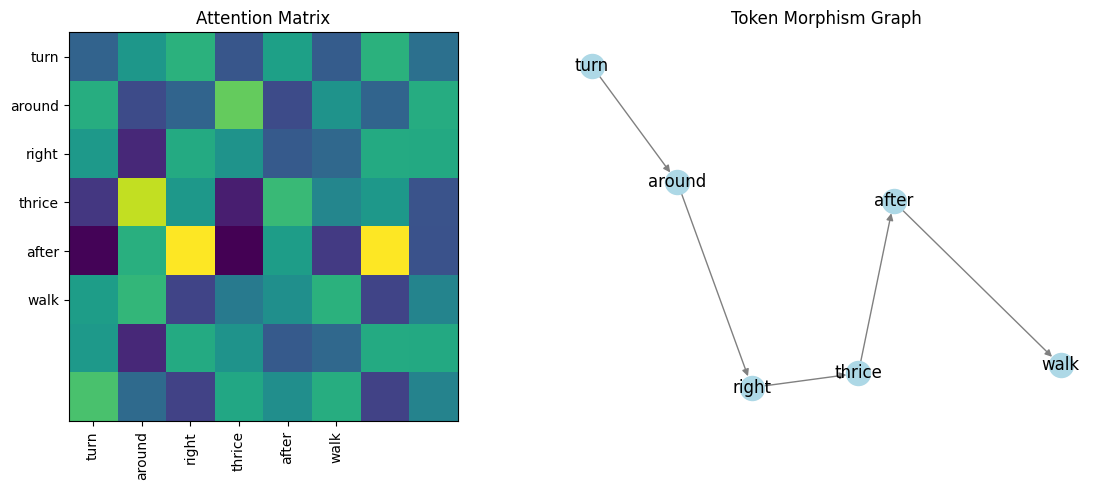

In [ ]:
visualize_attention_vs_morphisms(layer0_head0, [scan_token2id[t] for t in scan_example[:6]], scan_token2id)

Ablation (B) — Composition-Only FAM

Objective:

Test performance and structure when enforcing only composition preservation:

- λ₁ = 0.0 (no identity loss)

- λ₂ = 0.3 (composition loss only)

Model Setup

In [ ]:
model = FAMSeq2Seq(len(input_vocab), len(output_vocab)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=0)
early_stopper = EarlyStopper(patience=7)

λ1, λ2 = 0.0, 0.3  #  Composition-only

Training Loop

In [ ]:
for epoch in range(100):
    model.train()
    total_loss = 0.0

    for src_batch, tgt_batch in train_loader:
        src_batch, tgt_batch = src_batch.to(device), tgt_batch.to(device)
        optimizer.zero_grad()

        out_logits = model(src_batch, tgt_batch[:, :-1])
        logits_flat = out_logits.reshape(-1, out_logits.size(-1))
        tgt_flat = tgt_batch[:, 1:].reshape(-1)

        ce_loss = criterion(logits_flat, tgt_flat)
        f_loss = functor_loss(model.encoder.attn_weights, λ1=λ1, λ2=λ2)
        loss = ce_loss + f_loss

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    bleu_score = evaluate_bleu(model, train_dataset, input_vocab, output_vocab)
    print(f"Epoch {epoch+1} | Loss: {total_loss:.4f} | BLEU: {bleu_score:.2f}")

    if early_stopper.check(total_loss):
        print("Early stopping triggered.")
        break

Epoch 1 | Loss: 544.0305 | BLEU: 88.19
Epoch 2 | Loss: 345.6704 | BLEU: 89.05
Epoch 3 | Loss: 304.4334 | BLEU: 89.39
Epoch 4 | Loss: 282.4731 | BLEU: 89.29
Epoch 5 | Loss: 267.8694 | BLEU: 89.94
Epoch 6 | Loss: 256.5092 | BLEU: 89.50
Epoch 7 | Loss: 251.8922 | BLEU: 89.62
Epoch 8 | Loss: 243.4042 | BLEU: 90.18
Epoch 9 | Loss: 239.1396 | BLEU: 90.07
Epoch 10 | Loss: 236.2518 | BLEU: 89.76
Epoch 11 | Loss: 233.4585 | BLEU: 89.69
Epoch 12 | Loss: 228.6504 | BLEU: 90.30
Epoch 13 | Loss: 224.7613 | BLEU: 90.28
Epoch 14 | Loss: 221.2571 | BLEU: 89.95
Epoch 15 | Loss: 220.2156 | BLEU: 89.29
Epoch 16 | Loss: 215.4063 | BLEU: 90.44
Epoch 17 | Loss: 211.9323 | BLEU: 88.67
Epoch 18 | Loss: 209.4005 | BLEU: 89.91
Epoch 19 | Loss: 205.8636 | BLEU: 89.39
Epoch 20 | Loss: 204.6672 | BLEU: 89.71
Epoch 21 | Loss: 201.9519 | BLEU: 90.15
Epoch 22 | Loss: 199.3977 | BLEU: 89.69
Epoch 23 | Loss: 197.4485 | BLEU: 90.58
Epoch 24 | Loss: 192.2690 | BLEU: 90.47
Epoch 25 | Loss: 191.0753 | BLEU: 90.14
Epoch 26 

Post-Training Evaluation

After training ends:

In [ ]:
layer0_head0 = model.encoder.attn_weights[0][0, 0]

print("Identity violation:", check_identity_violation(layer0_head0).item())
print("Composition violation:", check_composition_violation(layer0_head0).item())

Identity violation: 0.8853392004966736
Composition violation: 0.003913146909326315


Visualize Attention vs Morphisms

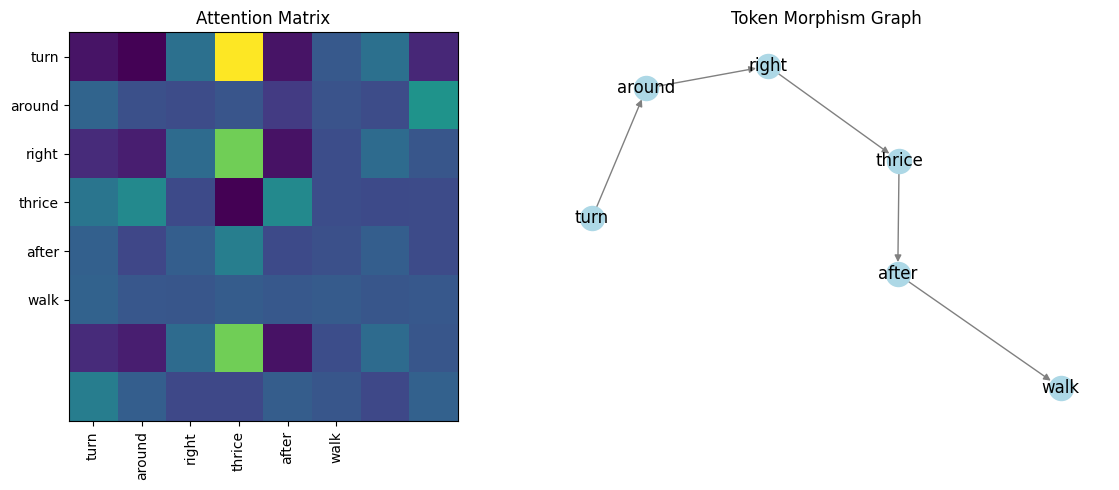

In [ ]:
visualize_attention_vs_morphisms(
    layer0_head0,
    [scan_token2id[t] for t in scan_example[:6]],
    scan_token2id
)